In [1]:
import pandas as pd
import numpy as np

import os

In [2]:
os.listdir()

['.ipynb_checkpoints', 'data', 'model_setup.ipynb', 'README.md']

In [3]:
file_name_list = os.listdir('./data')
file_name_list.pop()
# data path

'ufos.csv'

In [4]:
ufos = pd.read_csv('./data' + '/ufos.csv')

In [5]:
ufos.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700.0,45 minutes,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200.0,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.384210,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20.0,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.200000,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20.0,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900.0,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611


In [6]:
ufos.columns

Index(['datetime', 'city', 'state', 'country', 'shape', 'duration (seconds)',
       'duration (hours/min)', 'comments', 'date posted', 'latitude',
       'longitude'],
      dtype='object')

In [7]:
ufos.shape

(80332, 11)

In [8]:
col_rename_dict = {
    'duration (seconds)' : 'Seconds',
    'country' : 'Country',
    'latitude' : 'Latitude',
    'longitude' : 'Longitude'
}

ufos = ufos.rename(columns = col_rename_dict)[col_rename_dict.values()]

ufos.head()

,Seconds,Country,Latitude,Longitude
0,2700.0,us,29.883056,-97.941111
1,7200.0,NaN,29.384210,-98.581082
2,20.0,gb,53.200000,-2.916667
3,20.0,us,28.978333,-96.645833
4,900.0,us,21.418056,-157.803611


In [9]:
ufos['Country'].unique()

array(['us', nan, 'gb', 'ca', 'au', 'de'], dtype=object)

In [10]:
ufos.isna().sum()

Seconds         0
Country      9670
Latitude        0
Longitude       0
dtype: int64

In [11]:
ufos = ufos.dropna()

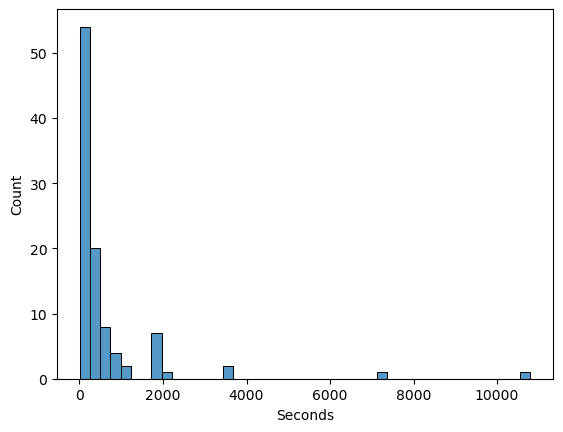

In [16]:
import seaborn as sns

sns.histplot(ufos['Seconds'].sample(100));

In [15]:
# data is largely right-skewed

In [28]:
def duration_category(x):
    if x <= 60:
        return '<=60'
    else:
        return '>= 60'

ufos['Seconds'] \
    .to_frame() \
    .assign(
        Duration = lambda x: x['Seconds'].apply(duration_category)
    ) \
    .value_counts('Duration', normalize=True)

Duration
>= 60    0.632872
<=60     0.367128
Name: proportion, dtype: float64

In [33]:
pd.cut(ufos['Seconds'], bins=[0, 60, float('inf')], labels=['<=60', '>60']).value_counts(normalize=True)

Seconds
>60     0.632872
<=60    0.367128
Name: proportion, dtype: float64

In [34]:
ufos = ufos[(ufos['Seconds'] >= 1) & (ufos['Seconds'] <= 60)]

ufos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25863 entries, 2 to 80330
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Seconds    25863 non-null  float64
 1   Country    25863 non-null  object 
 2   Latitude   25863 non-null  float64
 3   Longitude  25863 non-null  float64
dtypes: float64(3), object(1)
memory usage: 1010.3+ KB


In [37]:
ufos['Country'].unique()

array(['gb', 'us', 'ca', 'au', 'de'], dtype=object)

In [38]:
from sklearn.preprocessing import LabelEncoder

ufos['Country'] = LabelEncoder().fit_transform(ufos['Country'])

ufos.head()

,Seconds,Country,Latitude,Longitude
2,20.0,3,53.200000,-2.916667
3,20.0,4,28.978333,-96.645833
14,30.0,4,35.823889,-80.253611
23,60.0,4,45.582778,-122.352222
24,3.0,3,51.783333,-0.783333


In [39]:
ufos['Country'].unique()

array([3, 4, 1, 0, 2])

In [46]:
from sklearn.model_selection import train_test_split

X = ufos.drop(columns ='Country')
y = ufos['Country']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))
print('Accuracy: ', model.score(X_test, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       0.73      0.47      0.57       247
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00       158
           4       0.97      0.99      0.98      4717

    accuracy                           0.97      5173
   macro avg       0.94      0.89      0.91      5173
weighted avg       0.96      0.97      0.96      5173

Accuracy:  0.9663638121012952


In [57]:
import pickle
model_filename = 'ufo-model.pkl'
pickle.dump(model, open(model_filename, 'wb'))

In [58]:
model = pickle.load(open(model_filename,'rb'))
print(model.predict([[50,44,-12]]))

[3]


C:\Users\ErikOkushko\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
